# 데이터 전처리 



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler


# 모든 행과 열을 다 보이게 설정
# pd.set_option('display.max_rows', None)   # 행 전체 보기
# pd.set_option('display.max_columns', None)  # 열 전체 보기

data = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

# 사용할 컬럼만 선택
data = data[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]

# 결측치 처리
# 수치형 데이터는 평균값, 중앙값을 보통 이용한다.
# 범주형 데이터는 최빈값을 보통 이용한다.
data.loc[:, 'Age'] = data['Age'].fillna(data['Age'].mean())
data.loc[:, 'Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])
# Embarked : S / C / Q

# FamilySize 특성 추가
data['FamilySize'] = data['SibSp'] + data['Parch'] + 1


# 범주형 변수 원핫 인코딩
data = pd.get_dummies(data, columns=['Sex', 'Embarked'], drop_first=True)
# drop_first는 중복되는 컬럼을 제거한다. (Sex_Female을 지운것이다.)
# print(data.columns)


# 입력(X), 출력(y) 분리
X = data.drop('Survived', axis=1).values
y = data['Survived'].values.reshape(-1, 1)

# 데이터 정규화 (스케일링)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 스케일링 안하면 값이 큰 데이터 카테고리가 모델에서 영향력이 강해져. 결과값이 편향될 수 있다. 
# 그래서 스케일링을 한다.




In [2]:
data

,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.000000,1,0,7.2500,2,True,False,True
1,1,1,38.000000,1,0,71.2833,2,False,False,False
2,1,3,26.000000,0,0,7.9250,1,False,False,True
3,1,1,35.000000,1,0,53.1000,2,False,False,True
4,0,3,35.000000,0,0,8.0500,1,True,False,True
...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.000000,0,0,13.0000,1,True,False,True
887,1,1,19.000000,0,0,30.0000,1,False,False,True
888,0,3,29.699118,1,2,23.4500,4,False,False,True
889,1,1,26.000000,0,0,30.0000,1,True,False,False


# Logistic Regression


In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import numpy as np

# 모델 생성
lr_model = LogisticRegression(max_iter=1000)

# 5-Fold Cross Validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracies_lr = [] # 정확도
f1s_lr = [] # F1-score
aucs_lr = [] # ROC-AUC

for train_index, test_index in kf.split(X, y):
    X_train_cv, X_test_cv = X[train_index], X[test_index]
    y_train_cv, y_test_cv = y[train_index], y[test_index]

    lr_model.fit(X_train_cv, y_train_cv.ravel())
    y_pred = lr_model.predict(X_test_cv)
    y_prob = lr_model.predict_proba(X_test_cv)[:, 1]

    accuracies_lr.append(accuracy_score(y_test_cv, y_pred))
    f1s_lr.append(f1_score(y_test_cv, y_pred))
    aucs_lr.append(roc_auc_score(y_test_cv, y_prob))

print("=== Logistic Regression ===")
print("Accuracy:", np.mean(accuracies_lr))
print("F1-score:", np.mean(f1s_lr))
print("ROC-AUC:", np.mean(aucs_lr))


=== Logistic Regression ===
Accuracy: 0.7923984683949532
F1-score: 0.7215807023837559
ROC-AUC: 0.8526489572512475


# Random Forest


In [4]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
# n_estimators  : 생성할 결정 트리의 개수를 지정
# random_state : 난수설정, 랜덤 포레스트는 트리를 만들 때 랜덤하게 데이터 샘플링, 특성 선택을 사용


accuracies_rf = [] # 정확도
f1s_rf = [] # F1-score
aucs_rf = [] # ROC-AUC

for train_index, test_index in kf.split(X, y): # 데이터를 K개 fold로 나누기 위한 인덱스 생성기
    X_train_cv, X_test_cv = X[train_index], X[test_index]
    y_train_cv, y_test_cv = y[train_index], y[test_index]

    rf_model.fit(X_train_cv, y_train_cv.ravel())
    # y_train_cv.ravel() : 2차원 배열을 1차원으로 펼쳐서 모델이 처리 할 수 있게끔 한다.
    y_pred = rf_model.predict(X_test_cv)
    y_prob = rf_model.predict_proba(X_test_cv)[:, 1]  # 클래스1(생존) 확률만 선택
    # predict_proba : 각 샘플이 클래스별로 속할 확률을 반환 
    
    accuracies_rf.append(accuracy_score(y_test_cv, y_pred))
    f1s_rf.append(f1_score(y_test_cv, y_pred))
    aucs_rf.append(roc_auc_score(y_test_cv, y_prob))

print("=== Random Forest ===")
print("Accuracy:", np.mean(accuracies_rf))
print("F1-score:", np.mean(f1s_rf))
print("ROC-AUC:", np.mean(aucs_rf))


=== Random Forest ===
Accuracy: 0.8215491808423827
F1-score: 0.7645868335192497
ROC-AUC: 0.8704123480991195


# SVM

In [5]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True)

accuracies_svm = [] # 정확도
f1s_svm = [] # F1-score
aucs_svm = [] # ROC-AUC

for train_index, test_index in kf.split(X, y):
    X_train_cv, X_test_cv = X[train_index], X[test_index]
    y_train_cv, y_test_cv = y[train_index], y[test_index]

    svm_model.fit(X_train_cv, y_train_cv.ravel())
    y_pred = svm_model.predict(X_test_cv)
    y_prob = svm_model.predict_proba(X_test_cv)[:, 1]

    accuracies_svm.append(accuracy_score(y_test_cv, y_pred))
    f1s_svm.append(f1_score(y_test_cv, y_pred))
    aucs_svm.append(roc_auc_score(y_test_cv, y_prob))

print("=== SVM ===")
print("Accuracy:", np.mean(accuracies_svm))
print("F1-score:", np.mean(f1s_svm))
print("ROC-AUC:", np.mean(aucs_svm))


=== SVM ===
Accuracy: 0.8271420500910175
F1-score: 0.7536379076156454
ROC-AUC: 0.8577899101766391


# Gradient Boosting

In [6]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1)

accuracies_gb = [] # 정확도
f1s_gb = [] # F1-score
aucs_gb = [] # ROC-AUC

for train_index, test_index in kf.split(X, y):
    X_train_cv, X_test_cv = X[train_index], X[test_index]
    y_train_cv, y_test_cv = y[train_index], y[test_index]

    gb_model.fit(X_train_cv, y_train_cv.ravel())
    y_pred = gb_model.predict(X_test_cv)
    y_prob = gb_model.predict_proba(X_test_cv)[:, 1]

    accuracies_gb.append(accuracy_score(y_test_cv, y_pred))
    f1s_gb.append(f1_score(y_test_cv, y_pred))
    aucs_gb.append(roc_auc_score(y_test_cv, y_prob))

print("=== Gradient Boosting ===")
print("Accuracy:", np.mean(accuracies_gb))
print("F1-score:", np.mean(f1s_gb))
print("ROC-AUC:", np.mean(aucs_gb))


=== Gradient Boosting ===
Accuracy: 0.8372669637813068
F1-score: 0.7716314185922453
ROC-AUC: 0.8720035007149323


# 성능 비교

In [7]:
performance_table = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM", "Random Forest", "Gradient Boosting"],
    "Accuracy_avg": [
        np.mean(accuracies_lr),
        np.mean(accuracies_svm),
        np.mean(accuracies_rf),
        np.mean(accuracies_gb)
    ],
    "F1_Score_avg": [
        np.mean(f1s_lr),
        np.mean(f1s_svm),
        np.mean(f1s_rf),
        np.mean(f1s_gb)
    ],
    "ROC-AUC_avg": [
        np.mean(aucs_lr),
        np.mean(aucs_svm),
        np.mean(aucs_rf),
        np.mean(aucs_gb)
    ]
})

print(performance_table)


                 Model  Accuracy_avg  F1_Score_avg  ROC-AUC_avg
0  Logistic Regression      0.792398      0.721581     0.852649
1                  SVM      0.827142      0.753638     0.857790
2        Random Forest      0.821549      0.764587     0.870412
3    Gradient Boosting      0.837267      0.771631     0.872004


===== Fold별 성능표 =====
   Fold  LR_Accuracy     LR_F1  LR_ROC_AUC  SVM_Accuracy    SVM_F1  \
0     1     0.765363  0.700000    0.875428      0.843575  0.791045   
1     2     0.803371  0.728682    0.850134      0.820225  0.753846   
2     3     0.792135  0.699187    0.830816      0.803371  0.705882   
3     4     0.780899  0.715328    0.825602      0.837079  0.771654   
4     5     0.820225  0.764706    0.881266      0.831461  0.745763   

   SVM_ROC_AUC  RF_Accuracy     RF_F1  RF_ROC_AUC  GB_Accuracy     GB_F1  \
0     0.874374     0.821229  0.757576    0.904018     0.832402  0.761905   
1     0.871658     0.803371  0.748201    0.859826     0.848315  0.793893   
2     0.825602     0.814607  0.755556    0.841243     0.848315  0.776860   
3     0.864238     0.842697  0.787879    0.853409     0.820225  0.753846   
4     0.853078     0.825843  0.773723    0.893565     0.837079  0.771654   

   GB_ROC_AUC  
0    0.896706  
1    0.882420  
2    0.850535  
3    0.866176  
4    0.864180  




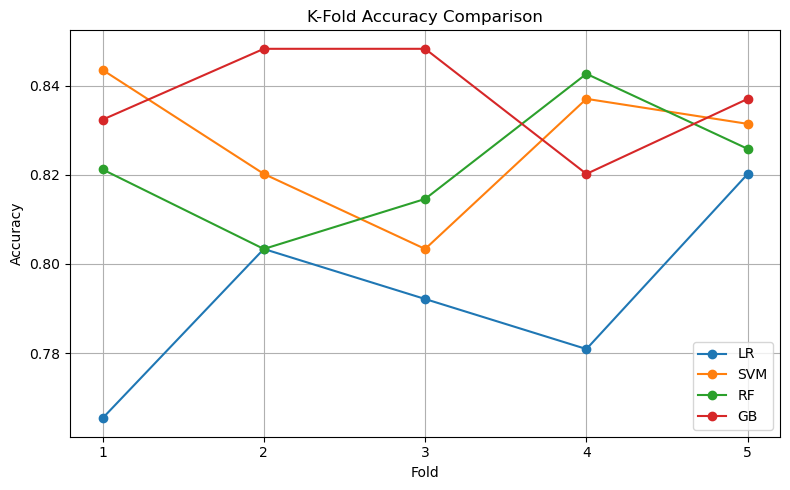

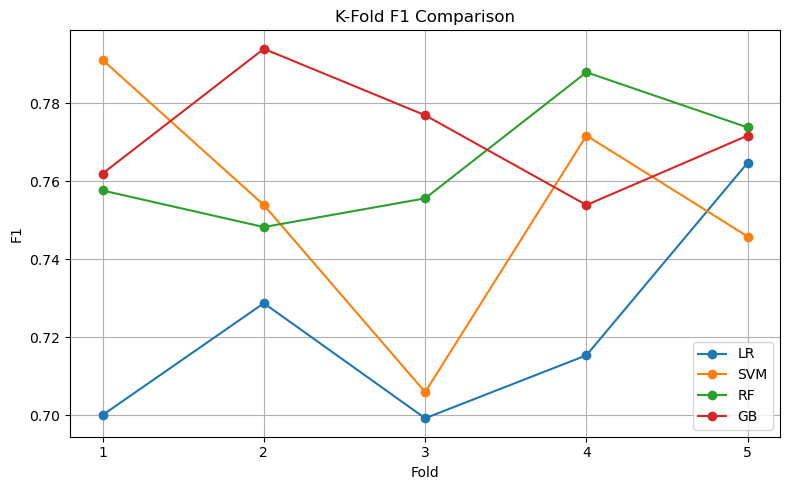

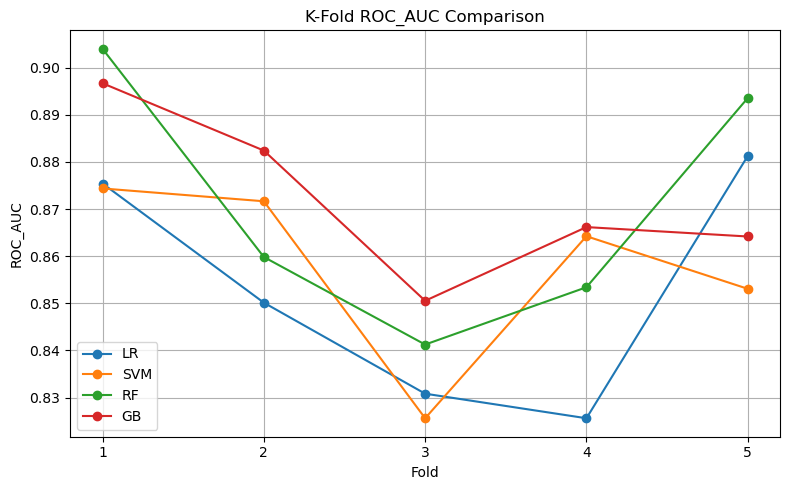

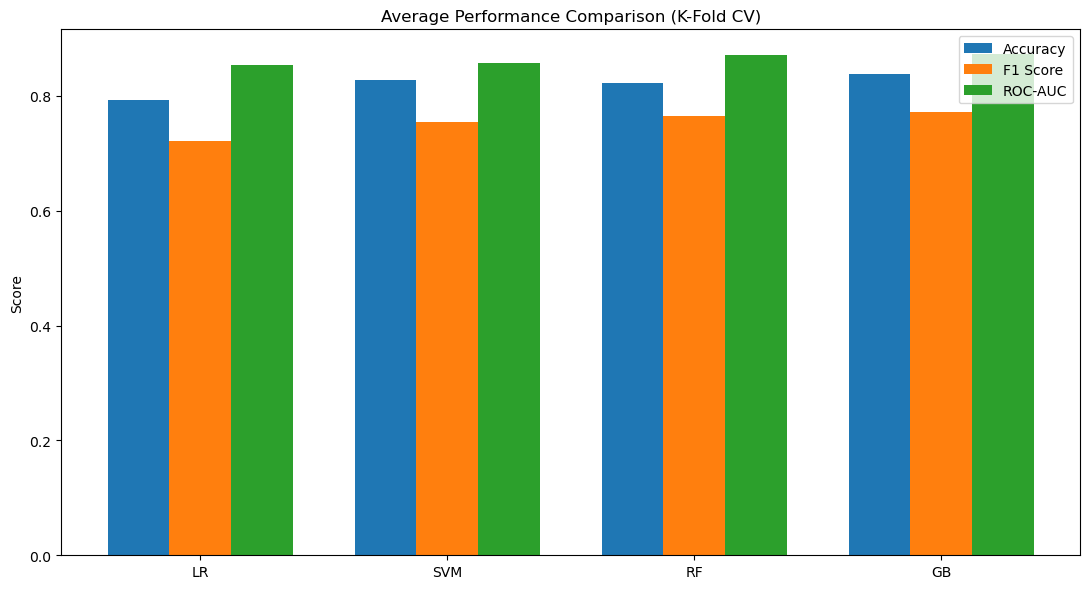

In [8]:
# Fold별 점수 DataFrame 생성

num_folds = len(accuracies_lr)
df_results = pd.DataFrame({
    "Fold": range(1, num_folds + 1),

    "LR_Accuracy":  accuracies_lr,
    "LR_F1":        f1s_lr,
    "LR_ROC_AUC":   aucs_lr,

    "SVM_Accuracy": accuracies_svm,
    "SVM_F1":       f1s_svm,
    "SVM_ROC_AUC":  aucs_svm,

    "RF_Accuracy":  accuracies_rf,
    "RF_F1":        f1s_rf,
    "RF_ROC_AUC":   aucs_rf,

    "GB_Accuracy":  accuracies_gb,
    "GB_F1":        f1s_gb,
    "GB_ROC_AUC":   aucs_gb
})

print("===== Fold별 성능표 =====")
print(df_results)
print("\n")

# Fold별 성능 선 그래프 

metrics = ["Accuracy", "F1", "ROC_AUC"]
models_short = ["LR", "SVM", "RF", "GB"]

for metric in metrics:
    plt.figure(figsize=(8, 5))
    plt.plot(df_results["Fold"], df_results[f"LR_{metric}"], marker='o', label="LR")
    plt.plot(df_results["Fold"], df_results[f"SVM_{metric}"], marker='o', label="SVM")
    plt.plot(df_results["Fold"], df_results[f"RF_{metric}"], marker='o', label="RF")
    plt.plot(df_results["Fold"], df_results[f"GB_{metric}"], marker='o', label="GB")

    plt.xlabel("Fold")
    plt.ylabel(metric)
    plt.title(f"K-Fold {metric} Comparison")
    plt.xticks(df_results["Fold"])
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# 평균값 비교 막대그래프 
x = np.arange(len(models_short))
width = 0.25

plt.figure(figsize=(11, 6))
plt.bar(x - width, performance_table["Accuracy_avg"], width, label="Accuracy")
plt.bar(x, performance_table["F1_Score_avg"], width, label="F1 Score")
plt.bar(x + width, performance_table["ROC-AUC_avg"], width, label="ROC-AUC")

plt.xticks(x, models_short)
plt.ylabel("Score")
plt.title("Average Performance Comparison (K-Fold CV)")
plt.legend()
plt.tight_layout()
plt.show()

# 각 모델별 하이퍼 파라미터 튜닝


In [9]:
from sklearn.model_selection import RandomizedSearchCV

# 1. Logistic Regression
lr_params = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

lr_random = RandomizedSearchCV(
    LogisticRegression(max_iter=1000),
    lr_params,
    cv=5,
    n_iter=5,
    scoring='roc_auc',
    random_state=42
)

lr_random.fit(X, y.ravel())

print("=== Logistic Regression Best Params ===")
print(lr_random.best_params_)
print("Best ROC-AUC:", lr_random.best_score_)



C:\Users\shin\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=5. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



=== Logistic Regression Best Params ===
{'solver': 'lbfgs', 'penalty': 'l2', 'C': 0.1}
Best ROC-AUC: 0.8502914868670752


In [10]:

# 2. SVM


svm_params = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}

svm_random = RandomizedSearchCV(
    SVC(probability=True),
    svm_params,
    cv=5,
    n_iter=6,
    scoring='roc_auc',
    random_state=42
)

svm_random.fit(X, y.ravel())

print("=== SVM Best Params ===")
print(svm_random.best_params_)
print("Best ROC-AUC:", svm_random.best_score_)





=== SVM Best Params ===
{'kernel': 'rbf', 'gamma': 'auto', 'C': 0.1}
Best ROC-AUC: 0.84205254876364


In [11]:


# 3. Random Forest
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 3, 5, 10]
}

rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    n_iter=6,
    scoring='roc_auc',
    random_state=42
)

rf_random.fit(X, y.ravel())

print("=== Random Forest Best Params ===")
print(rf_random.best_params_)
print("Best ROC-AUC:", rf_random.best_score_)



=== Random Forest Best Params ===
{'n_estimators': 300, 'max_depth': 5}
Best ROC-AUC: 0.8704008242162586


In [12]:

# 4. Gradient Boosting
gb_params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4]
}

gb_random = RandomizedSearchCV(
    GradientBoostingClassifier(),
    gb_params,
    cv=5,
    n_iter=6,
    scoring='roc_auc',
    random_state=42
)

gb_random.fit(X, y.ravel())

print("=== Gradient Boosting Best Params ===")
print(gb_random.best_params_)
print("Best ROC-AUC:", gb_random.best_score_)


=== Gradient Boosting Best Params ===
{'n_estimators': 200, 'max_depth': 2, 'learning_rate': 0.05}
Best ROC-AUC: 0.8713587125389374


# 결과 분석

## 1). 튜닝 전 성능
- 전반적으로 Gradient Boosting과 Random Forest가 가장 높은 성능을 보였다.
- Gradient Boosting이 ROC-AUC에서 0.872로 최고 성능을 보였다.

| Model                  | Accuracy | F1 Score | ROC-AUC |
|------------------------|---------|----------|---------|
| Logistic Regression    | 0.7924  | 0.7216   | 0.8526  |
| Random Forest          | 0.8215  | 0.7646   | 0.8704  |
| SVM                    | 0.8271  | 0.7536   | 0.8578  |
| Gradient Boosting      | 0.8373  | 0.7716   | 0.8720  |


## 2). 튜닝 후 성능
- Logistic Regression : ROC-AUC 변화 거의 없다.
- Random Forest : ROC-AUC 변화 거의 없다.
- SVM : ROC-AUC가 튜닝 후 오히려 낮아졌다.
- Gradient Boosting : ROC-AUC 변화 거의 없다.

| Model                  | Best Hyperparameters                               | ROC-AUC (Tuned) |
|------------------------|---------------------------------------------------|-----------------|
| Logistic Regression    | {'solver': 'lbfgs', 'penalty': 'l2', 'C': 0.1} | 0.8503          |
| Random Forest          | {'n_estimators': 300, 'max_depth': 5}          | 0.8704          |
| SVM                    | {'kernel': 'rbf', 'gamma': 'auto', 'C': 0.1}   | 0.8421          |
| Gradient Boosting      | {'n_estimators': 200, 'max_depth': 2, 'learning_rate': 0.05} | 0.8714 |


## 3). 결론
- Logistic Regression : 전체 성능 자체가 다른 모델보다 낮았다.
 선형 모델 특성상 데이터 내 영향력이 낮은 변수에 대한 영향력이 제한적이었던 것이 원인으로 보인다.

  
- Random Forest : 안정적인 Ensemble 구조라서 튜닝 전후 성능 차이가 적은 것으로 보인다. 


- SVM : 튜닝 후 성능이 떨어졌다.
- SVM은 거리 기반 모델 이기 때문에 데이터 스케일링과 하이퍼 파라미터 민감도가 높다.
- 다만, 데이터를 정규화하고 학습했기 때문에 gamma의 영향은 미미하다고 볼 수 있다.
- C(규제)를 작게 하여 튜닝하였음에도 성능변화는 미미하였다.

- Gradient Boosting : 튜닝 전후 성능이 거의 동일한 것으로 보아 이미 기본 하이퍼 파라미터 설정만으로도 성능이 충분히 좋았던 것으로 보인다.

- 최종적으로 가장 좋은 모델을 뽑는다면 "Gradient Boosting 모델"이다.
- 가장 높은 ROC-AUC
- Accuracy 및 F1-Score 모두 높은 성능
- 튜닝 전후 성능이 안정적이라 모델의 안정성을 신뢰할 수 있다.
- Max_Depth가 2로 모델을 해석하는 데 용이하다.